In [1]:
import polars as pl
import pandas as pd  # needed for bambi 
import bambi
import arviz as az
import itertools
import matplotlib.pyplot as plt
import arviz_plots as azp

# Difference Analysis

## Linguistic Features

In [2]:
df = pl.read_csv("rq1_results.csv", separator=";")

In [3]:
df.head()

fold,n_train_positive,n_train_negative,n_test_positive,n_test_negative,model,prompt_condition,language,topic,stance,feature_area,accuracy,precision,recall,f1,tn,fp,fn,tp
i64,i64,i64,i64,i64,str,str,str,str,str,str,f64,f64,f64,f64,i64,i64,i64,i64
0,444,12,111,3,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""","""named_entities""",0.7342,1.0,0.4685,0.6237,3,0,59,52
1,444,12,111,3,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""","""named_entities""",0.7387,1.0,0.4775,0.6318,3,0,58,53
2,444,12,111,3,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""","""named_entities""",0.7838,1.0,0.5676,0.708,3,0,48,63
3,444,12,111,3,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""","""named_entities""",0.7883,1.0,0.5766,0.7152,3,0,47,64
4,444,12,111,3,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""","""named_entities""",0.7568,1.0,0.5135,0.6633,3,0,54,57


In [4]:
df["model"].value_counts()

model,count
str,u32
"""gpt-4.1-mini""",37416
"""occiglot-7b-eu5-instruct""",37008
"""llama_4_scout""",37416
"""llama_3.1-8b-instruct""",36420


In [5]:
for feature_area in df["feature_area"].unique():
    if len(feature_area) < 15:
        printed_area = feature_area + " " * (15 - len(feature_area))
    else:
        printed_area = feature_area
    print("& ", printed_area, "\t & ", f"{df.filter(pl.col("feature_area") == feature_area)['accuracy'].mean():.3f} & {df.filter(pl.col("feature_area") == feature_area)['accuracy'].std():.3f}\\\\")

&  dependencies    	 &  0.798 & 0.134\\
&  morphological   	 &  0.779 & 0.162\\
&  semantics       	 &  0.773 & 0.147\\
&  all_features    	 &  0.967 & 0.096\\
&  readability     	 &  0.939 & 0.097\\
&  emotion         	 &  0.825 & 0.156\\
&  psycholinguistics 	 &  0.722 & 0.168\\
&  lexical_richness 	 &  0.965 & 0.089\\
&  pos             	 &  0.806 & 0.146\\
&  information     	 &  0.871 & 0.126\\
&  named_entities  	 &  0.668 & 0.152\\
&  surface         	 &  0.937 & 0.094\\


In [6]:
# transform conditions into binary variables
df = df.with_columns(
    pl.when(pl.col("prompt_condition") == "C")
    .then(1)
    .when(pl.col("prompt_condition").str.contains("C +"))
    .then(1)
    .otherwise(0)
    .alias("context"),
    pl.when(pl.col("prompt_condition").str.contains("P&C"))
    .then(1)
    .otherwise(0)
    .alias("examples"),
    pl.when(pl.col("prompt_condition").str.contains("Ex"))
    .then(1)
    .otherwise(0).alias("explanation"),
    pl.when(pl.col("prompt_condition").str.contains("SD"))
    .then(1)
    .otherwise(0).alias("sociodemographics"),
)

### Overall model

In [7]:
formula = "accuracy_adj ~ "
# "feature_area + "
formula += "context + examples + explanation + sociodemographics + model + stance + topic + language"
for comb in itertools.combinations(
    # ["context", "examples", "explanation", "sociodemographics", "feature_area"], 2
    ["context", "examples", "explanation", "sociodemographics"], 2
):
    formula += f" + {comb[0]}:{comb[1]}"
formula += " + stance:topic + topic:model"

In [8]:
data = df.filter(pl.col("feature_area") == "all_features").to_pandas()
# data = df.to_pandas()
n = len(data)
data["accuracy_adj"] = (data["accuracy"] * (n - 1) + 0.5) / n
model = bambi.Model(
    formula,
    data=data,
    family="beta",
    categorical=["model", "stance", "topic", "language"],
    )

In [9]:
data["feature_area"].value_counts()

feature_area
all_features    12355
Name: count, dtype: int64

In [10]:
model

       Formula: accuracy_adj ~ context + examples + explanation + sociodemographics + model + stance + topic + language + context:examples + context:explanation + context:sociodemographics + examples:explanation + examples:sociodemographics + explanation:sociodemographics + stance:topic + topic:model
        Family: beta
          Link: mu = logit
  Observations: 12355
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 8.9067)
            context ~ Normal(mu: 0.0, sigma: 5.0)
            examples ~ Normal(mu: 0.0, sigma: 5.0582)
            explanation ~ Normal(mu: 0.0, sigma: 5.0134)
            sociodemographics ~ Normal(mu: 0.0, sigma: 5.3142)
            model ~ Normal(mu: [0. 0. 0.], sigma: [5.8076 5.7554 5.7765])
            stance ~ Normal(mu: 0.0, sigma: 5.001)
            topic ~ Normal(mu: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], sigma: [ 9.7098 10.0717  7.49
                14.8639  9.3567  7.4779 13.9081  9.3746  9.290

In [11]:
results = model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, context, examples, explanation, sociodemographics, model, stance, topic, language, context:examples, context:explanation, context:sociodemographics, examples:explanation, examples:sociodemographics, explanation:sociodemographics, stance:topic, topic:model]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 49 seconds.


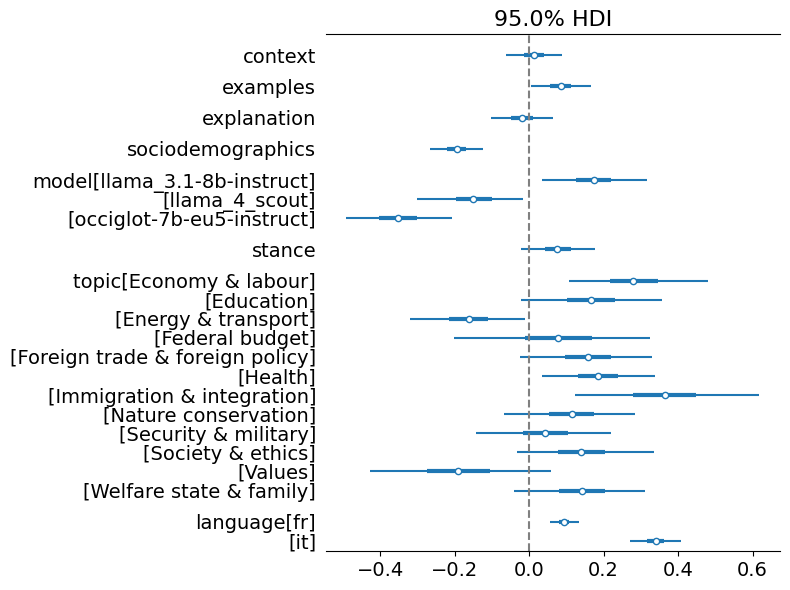

In [12]:
axes = az.plot_forest(results, 
               combined=True,
               var_names=[
                     "context",
                     "examples",
                     "explanation",
                     "sociodemographics",
                     "model",
                     "stance",
                     "topic",
                     "language",
               ],
               figsize=(8, 6),
               hdi_prob=0.95,
               )
# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

plt.tight_layout()
plt.savefig("model_rq1_ling_all.pdf")
plt.show()

In [13]:
az.summary(results).to_csv("summaries/model_rq1_ling_all_summary.csv")

In [14]:
az.to_netcdf(results, "models/model_rq1_ling_all.nc")

'models/model_rq1_ling_all.nc'

In [ ]:
results = az.from_netcdf("models/model_rq1_all_full.nc")

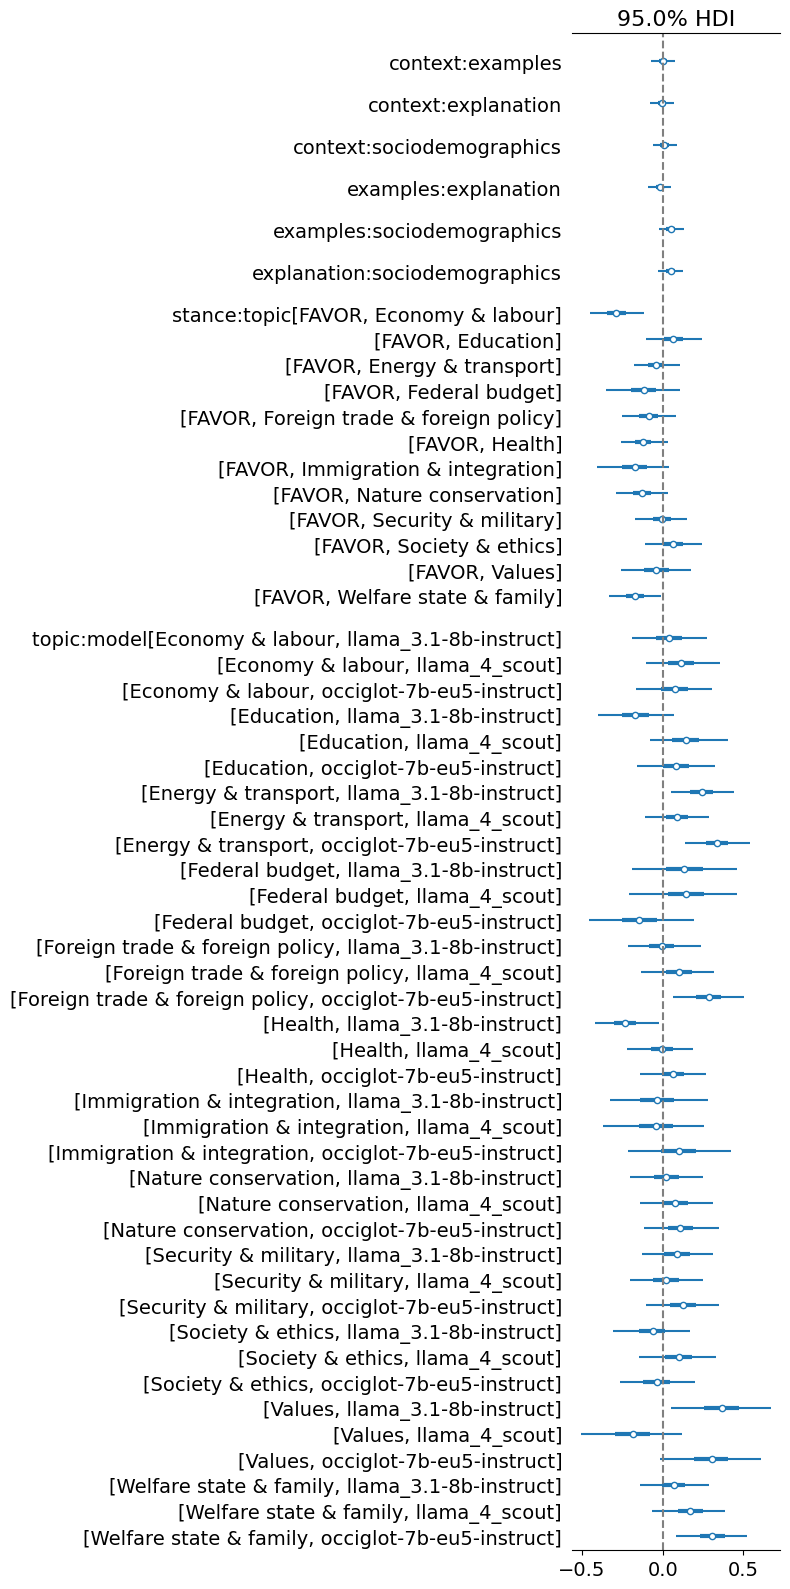

In [16]:
axes = az.plot_forest(results, 
               combined=True,
               var_names=[
                     "context:examples",
                     "context:explanation",
                     "context:sociodemographics",
                     "examples:explanation",
                     "examples:sociodemographics",
                     "explanation:sociodemographics",
                     "stance:topic",
                        "topic:model",
               ],
               figsize=(8, 16),
               hdi_prob=0.95,
               )
# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

plt.tight_layout()
# plt.savefig("model_rq3_all_forest_no-area-main.pdf")
plt.show()

### Regression model per feature area

In [ ]:
formula = "accuracy_adj ~ context + examples + explanation + sociodemographics + model + stance + topic + language"
for comb in itertools.combinations(
    ["context", "examples", "explanation", "sociodemographics"], 2
):
    formula += f" + {comb[0]}:{comb[1]}"

for area in df["feature_area"].unique():
    subset_data = df.filter(pl.col("feature_area") == area).to_pandas()

    n = len(subset_data)
    # apply smithson-verkuilen correction to accuracy values
    subset_data["accuracy_adj"] = (subset_data["accuracy"] * (n - 1) + 0.5) / n
    model = bambi.Model(
        formula,
        data=subset_data,
        family="beta",
        categorical=["model", "stance", "topic", "language"],
    )
    az.summary(model.fit()).to_csv(f"model_rq1_{area}_summary-limited.csv")
    az.to_netcdf(model.fit(), f"model_rq1_{area}_limited.nc")

## SBERT

In [21]:
df = pl.read_csv("results/rq1_sbert_results.csv", separator=";")

In [22]:
df.describe()

statistic,fold,n_train_positive,n_train_negative,n_test_positive,n_test_negative,model,prompt_condition,language,topic,stance,accuracy,precision,recall,f1,tn,fp,fn,tp
str,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",12355.0,12355.0,12355.0,12355.0,12355.0,"""12355""","""12355""","""12355""","""12355""","""12355""",12355.0,12355.0,12355.0,12355.0,12355.0,12355.0,12355.0,12355.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.927317,189.796924,111.383893,47.430676,27.882315,null,null,null,null,null,0.902053,0.976356,0.89788,0.963447,27.488628,0.393687,1.8845,45.546176
"""std""",1.404643,169.716348,116.31961,42.430285,29.048386,null,null,null,null,null,0.145141,0.115687,0.176656,0.037825,28.831702,0.94194,2.03948,41.953699
"""min""",0.0,7.0,1.0,1.0,1.0,"""gpt-4.1-mini""","""C""","""de""","""Democracy, Media & Digitizatio…","""AGAINST""",0.3966,0.0,0.0,0.6178,0.0,0.0,0.0,0.0
"""25%""",1.0,57.0,8.0,14.0,2.0,null,null,null,null,null,0.8913,0.9914,0.8919,0.9489,2.0,0.0,0.0,13.0
"""50%""",2.0,138.0,84.0,34.0,21.0,null,null,null,null,null,0.9659,1.0,0.9643,0.9726,21.0,0.0,1.0,33.0
"""75%""",3.0,263.0,161.0,66.0,40.0,null,null,null,null,null,0.9928,1.0,1.0,0.9905,39.0,1.0,3.0,65.0
"""max""",4.0,683.0,648.0,171.0,162.0,"""occiglot-7b-eu5-instruct""","""SD + P&C""","""it""","""Welfare state & family""","""FAVOR""",1.0,1.0,1.0,1.0,162.0,16.0,17.0,171.0


In [23]:
# transform conditions into binary variables
df = df.with_columns(
    pl.when(pl.col("prompt_condition") == "C")
    .then(1)
    .when(pl.col("prompt_condition").str.contains("C +"))
    .then(1)
    .otherwise(0)
    .alias("context"),
    pl.when(pl.col("prompt_condition").str.contains("P&C"))
    .then(1)
    .otherwise(0)
    .alias("examples"),
    pl.when(pl.col("prompt_condition").str.contains("Ex"))
    .then(1)
    .otherwise(0).alias("explanation"),
    pl.when(pl.col("prompt_condition").str.contains("SD"))
    .then(1)
    .otherwise(0).alias("sociodemographics"),
)

In [24]:
formula = "accuracy_adj ~ context + examples + explanation + sociodemographics + model + stance + topic + language"
for comb in itertools.combinations(
    ["context", "examples", "explanation", "sociodemographics"], 2
):
    formula += f" + {comb[0]}:{comb[1]}"
formula += " + stance:topic + topic:model"

In [25]:
data = df.to_pandas()
n = len(data)
data["accuracy_adj"] = (data["accuracy"] * (n - 1) + 0.5) / n
model = bambi.Model(
    formula,
    data=data,
    family="beta",
    categorical=["model", "stance", "topic", "language"],
    )

In [26]:
results = model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, context, examples, explanation, sociodemographics, model, stance, topic, language, context:examples, context:explanation, context:sociodemographics, examples:explanation, examples:sociodemographics, explanation:sociodemographics, stance:topic, topic:model]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 56 seconds.


In [30]:
az.to_netcdf(results, f"models/rq1_sbert.nc")

'models/rq1_sbert.nc'

In [31]:
az.summary(results).to_csv("results/rq1_sbert_summary.csv")

### Plot both

In [32]:
elfen = az.from_netcdf("models/model_rq1_ling_all.nc")
sbert = az.from_netcdf("models/rq1_sbert.nc")

/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_19865/2717694378.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


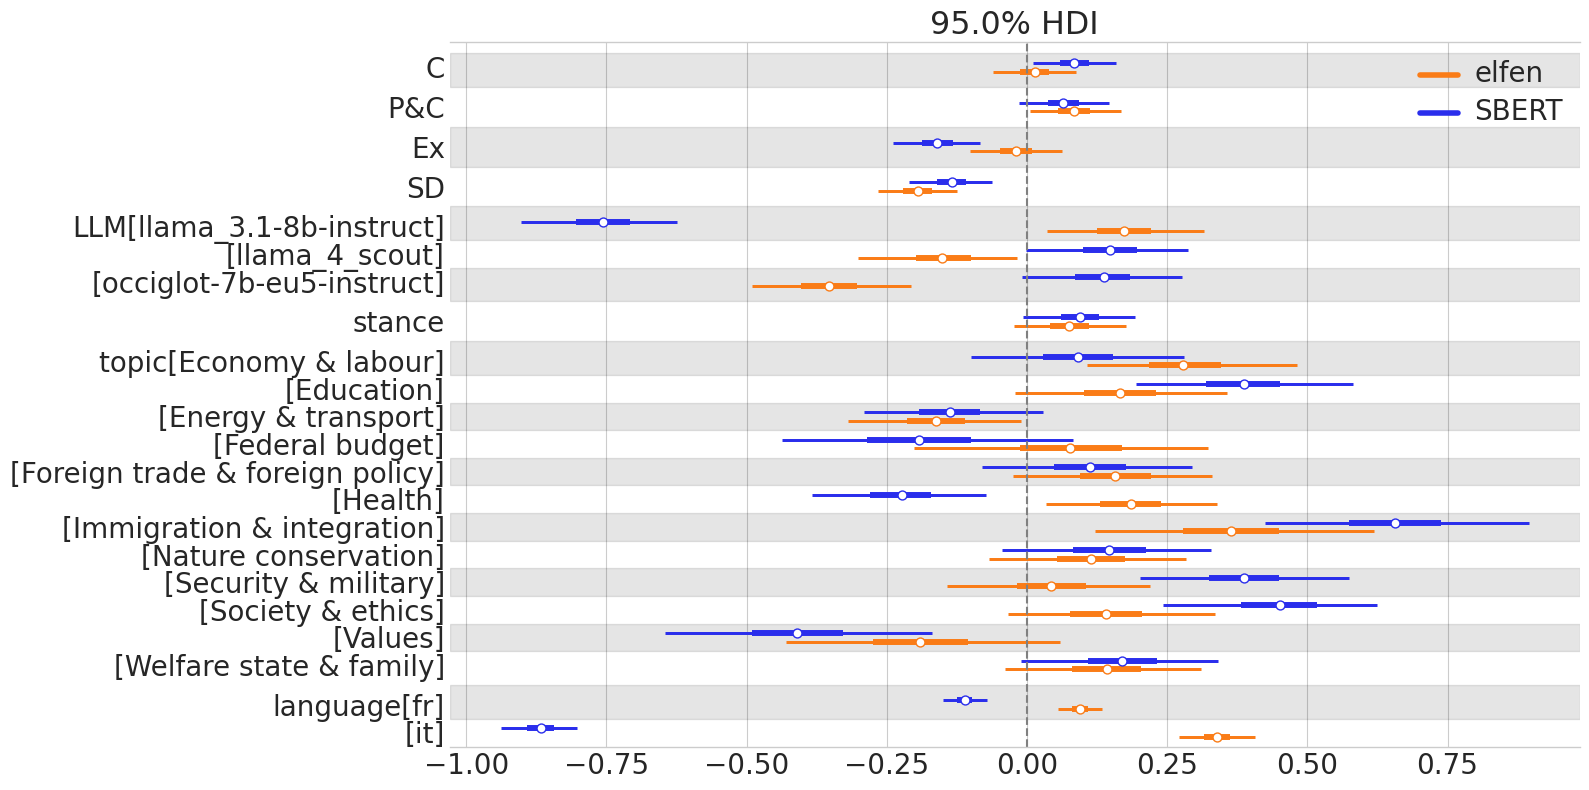

In [44]:
sbert = sbert.rename_vars(
    {
        "model": "LLM",
        "context": "C",
        "examples": "P&C",
        "explanation": "Ex",
        "sociodemographics": "SD",
        "context:examples": "C:P&C",
        "context:explanation": "C:Ex",
        "context:sociodemographics": "C:SD",
        "examples:explanation": "P&C:Ex",
        "examples:sociodemographics": "P&C:SD",
        "explanation:sociodemographics": "Ex:SD",
   }
)
elfen = elfen.rename_vars(
    {
        "model": "LLM",
        "context": "C",
        "examples": "P&C",
        "explanation": "Ex",
        "sociodemographics": "SD",
        "context:examples": "C:P&C",
        "context:explanation": "C:Ex",
        "context:sociodemographics": "C:SD",
        "examples:explanation": "P&C:Ex",
        "examples:sociodemographics": "P&C:SD",
        "explanation:sociodemographics": "Ex:SD",
   }
)
az.style.use("arviz-whitegrid")

axes = az.plot_forest(
               [sbert, elfen],
                model_names=["SBERT", "elfen"],
               combined=True,
               var_names=[
                     "C",
                     "P&C",
                     "Ex",
                     "SD",
                     "LLM",
                     "stance",
                     "topic",
                     "language",
               ],
                hdi_prob=0.95,
               figsize=(16, 8),
               textsize=20,
)

# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

legend = axes[0].get_legend()
for text in legend.get_texts():
    text.set_fontsize(20)
for line in legend.get_lines():
    line.set_linewidth(4)

plt.tight_layout()
plt.savefig("model_rq1_both.pdf")
plt.show()

/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_19865/1216177663.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


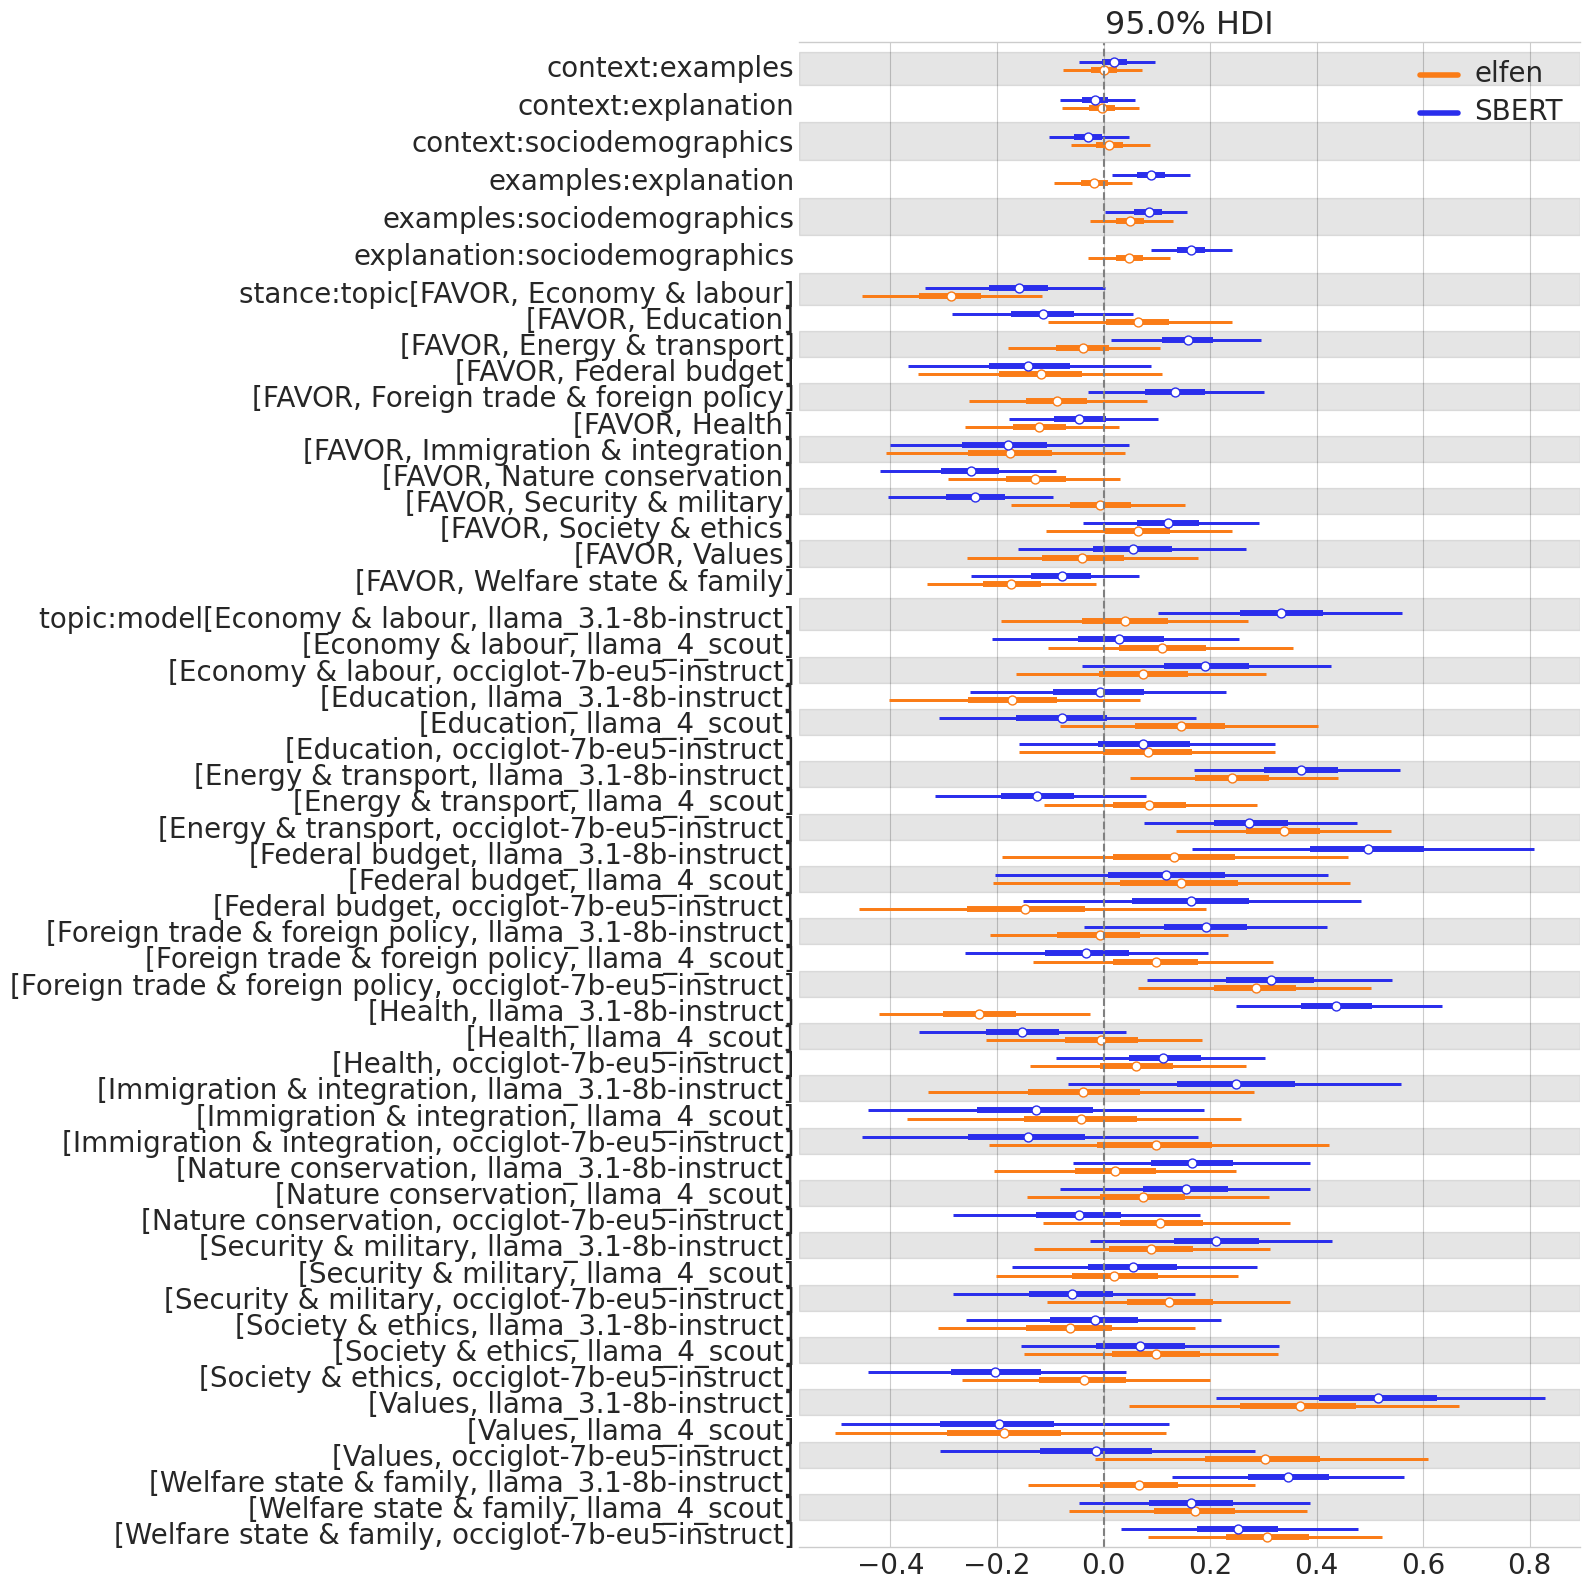

In [40]:
axes = az.plot_forest([sbert, elfen],
               model_names=["SBERT", "elfen"],
               combined=True,
               var_names=[
                     "context:examples",
                     "context:explanation",
                     "context:sociodemographics",
                     "examples:explanation",
                     "examples:sociodemographics",
                     "explanation:sociodemographics",
                     "stance:topic",
                        "topic:model",
               ],
                              hdi_prob=0.95,
               figsize=(16, 16),
               textsize=20,
)

# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

legend = axes[0].get_legend()
for text in legend.get_texts():
    text.set_fontsize(20)
for line in legend.get_lines():
    line.set_linewidth(4)

plt.tight_layout()
plt.savefig("model_rq1_both_interactions.pdf")
plt.show()

# Stability Analysis

## Rogue-L Scores

In [ ]:
de = pl.read_csv("rogueL_scores_de.csv")
fr = pl.read_csv("rogueL_scores_fr.csv")
it = pl.read_csv("rogueL_scores_it.csv")

prompts_de = pl.read_csv("prompts_de.csv")
prompts_fr = pl.read_csv("prompts_fr.csv")
prompts_it = pl.read_csv("prompts_it.csv")

In [ ]:
de.select(pl.col("prompt_id")).n_unique() == prompts_de.select(pl.col("id")).n_unique()

In [ ]:
fr.select(pl.col("prompt_id")).n_unique() == prompts_fr.select(pl.col("id")).n_unique()

In [ ]:
it.select(pl.col("prompt_id")).n_unique() == prompts_it.select(pl.col("id")).n_unique()

In [ ]:
de = de.join(prompts_de, left_on="prompt_id", right_on="id", how="inner")
fr = fr.join(prompts_fr, left_on="prompt_id", right_on="id", how="inner")
it = it.join(prompts_it, left_on="prompt_id", right_on="id", how="inner")

In [ ]:
df = pl.concat([de, fr, it], how="vertical")

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
corpus = pl.read_csv("full_corpus.csv")

In [ ]:
# join corpus with df to get topic for each prompt
df = df.join(corpus.select(["prompt_id", "topic"]).unique(), on="prompt_id", how="inner")

In [ ]:
df.shape

In [ ]:
del de, fr, it, prompts_de, prompts_fr, prompts_it, corpus

In [ ]:
df = df.with_columns(
    (pl.when(pl.col("prompt_id").str.starts_with("de"))
    .then(pl.lit("de"))
    .when(pl.col("prompt_id").str.starts_with("fr"))
    .then(pl.lit("fr"))
    .when(pl.col("prompt_id").str.starts_with("it"))
    .then(pl.lit("it"))).alias("language"),
    pl.when(pl.col("sociodemographic_info").is_not_null())
    .then(pl.lit(1))
    .otherwise(pl.lit(0)).alias("sociodemographics"),
    pl.when(pl.col("info").is_not_null())
    .then(pl.lit(1))
    .otherwise(pl.lit(0)).alias("explanation"),
    pl.when(pl.col("pro").is_not_null())
    .then(1)
    .when(pl.col("contra").is_not_null())
    .then(1)
    .otherwise(0).alias("examples"),
    pl.when(pl.col("context") == True)
    .then(1)
    .otherwise(0).alias("context"),
)

In [ ]:
df.describe()

In [ ]:
formula = "f1_adj ~ context + examples + explanation + sociodemographics + model + stance + topic + language"
for comb in itertools.combinations(
    ["context", "examples", "explanation", "sociodemographics"], 2
):
    formula += f" + {comb[0]}:{comb[1]}"
formula += " + stance:topic + model:topic"

data = df.to_pandas()
n = len(data)
data["f1_adj"] = (data["average_F1"] * (n - 1) + 0.5) / n

model = bambi.Model(
    formula,
    data=data,
    family="beta",
    categorical=["model", "stance", "topic", "language"],
)

In [ ]:
results_rogue = model.fit()

In [ ]:
axes = az.plot_forest(results_rogue, 
               combined=True,
               var_names=[
                     "context",
                     "examples",
                     "explanation",
                     "sociodemographics",
                     "model",
                     "stance",
                     "topic",
                     "language",
               ],
               figsize=(8, 6),
               hdi_prob=0.95,
               )
# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

plt.tight_layout()
plt.savefig("model_rq3_all_forest_no-area-main.pdf")
plt.show()

In [ ]:
axes = az.plot_forest(results_rogue, 
               combined=True,
               var_names=[
                     "context:examples",
                     "context:explanation",
                     "context:sociodemographics",
                     "examples:explanation",
                     "examples:sociodemographics",
                     "explanation:sociodemographics",
                     "stance:topic",
                        "model:topic"
               ],
               figsize=(8, 16),
               hdi_prob=0.95,
               )
# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

plt.tight_layout()
plt.savefig("model_rq3_all_forest_no-area-main.pdf")
plt.show()

In [ ]:
az.summary(results_rogue).to_csv(f"model_rq2_rogueL_summary+topic:model.csv")

In [ ]:
# save model results to netcdf file
az.to_netcdf(results_rogue, f"models/model_rq2_rogueL_full+topic:model.nc")

## BERTScore

In [ ]:
de = pl.read_csv("bert_score_de.csv")
fr = pl.read_csv("bert_score_fr.csv")
it = pl.read_csv("bert_score_it.csv")

prompts_de = pl.read_csv("prompts_de.csv")
prompts_fr = pl.read_csv("prompts_fr.csv")
prompts_it = pl.read_csv("prompts_it.csv")

In [ ]:
de.select(pl.col("prompt_id")).n_unique() == prompts_de.select(pl.col("id")).n_unique()

In [ ]:
fr.select(pl.col("prompt_id")).n_unique() == prompts_fr.select(pl.col("id")).n_unique()

In [ ]:
it.select(pl.col("prompt_id")).n_unique() == prompts_it.select(pl.col("id")).n_unique()

In [ ]:
de = de.join(prompts_de, left_on="prompt_id", right_on="id", how="inner")
fr = fr.join(prompts_fr, left_on="prompt_id", right_on="id", how="inner")
it = it.join(prompts_it, left_on="prompt_id", right_on="id", how="inner")

In [ ]:
df = pl.concat([de, fr, it], how="vertical")
df.head()

In [ ]:
corpus = pl.read_csv("full_corpus.csv")
# join corpus with df to get topic for each prompt
df = df.join(corpus.select(["prompt_id", "topic"]).unique(), on="prompt_id", how="inner")

In [ ]:
del de, fr, it, prompts_de, prompts_fr, prompts_it, corpus

In [ ]:
df = df.with_columns(
    (pl.when(pl.col("prompt_id").str.starts_with("de"))
    .then(pl.lit("de"))
    .when(pl.col("prompt_id").str.starts_with("fr"))
    .then(pl.lit("fr"))
    .when(pl.col("prompt_id").str.starts_with("it"))
    .then(pl.lit("it"))).alias("language"),
    pl.when(pl.col("sociodemographic_info").is_not_null())
    .then(pl.lit(1))
    .otherwise(pl.lit(0)).alias("sociodemographics"),
    pl.when(pl.col("info").is_not_null())
    .then(pl.lit(1))
    .otherwise(pl.lit(0)).alias("explanation"),
    pl.when(pl.col("pro").is_not_null())
    .then(1)
    .when(pl.col("contra").is_not_null())
    .then(1)
    .otherwise(0).alias("examples"),
    pl.when(pl.col("context") == True)
    .then(1)
    .otherwise(0).alias("context"),
)

In [ ]:
df.head()

In [ ]:
formula = "f1_adj ~ context + examples + explanation + sociodemographics + model + stance + topic + language"
for comb in itertools.combinations(
    ["context", "examples", "explanation", "sociodemographics"], 2
):
    formula += f" + {comb[0]}:{comb[1]}"
formula += " + stance:topic + model:topic"

data = df.to_pandas()
n = len(data)
data["f1_adj"] = (data["f1"] * (n - 1) + 0.5) / n

model = bambi.Model(
    formula,
    data=data,
    family="beta",
    categorical=["model", "stance", "topic", "language"],
)

In [ ]:
results_bertscore = model.fit()

In [ ]:
axes = az.plot_forest(results_bertscore, 
               combined=True,
               var_names=[
                     "context",
                     "examples",
                     "explanation",
                     "sociodemographics",
                     "model",
                     "stance",
                     "topic",
                     "language",
               ],
               figsize=(8, 6),
               hdi_prob=0.95,
               )
# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

plt.tight_layout()
# plt.savefig("model_rq3_all_forest_no-area-main.pdf")
plt.show()

In [ ]:
axes = az.plot_forest(results_bertscore, 
               combined=True,
               var_names=[
                     "context:examples",
                     "context:explanation",
                     "context:sociodemographics",
                     "examples:explanation",
                     "examples:sociodemographics",
                     "explanation:sociodemographics",
                     "stance:topic",
                        "model:topic",
               ],
               figsize=(8, 16),
               hdi_prob=0.95,
               )
# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

plt.tight_layout()
# plt.savefig("model_rq3_all_forest_no-area-main.pdf")
plt.show()

In [ ]:
az.summary(results_bertscore).to_csv(f"model_rq2_bertscore_summary+topic:model.csv")

In [ ]:
az.to_netcdf(results_bertscore, f"models/model_rq2_bertscore_full+topic:model.nc")

## Both

In [ ]:
results_rogue = az.from_netcdf("models/model_rq2_rogueL_full+topic:model.nc")
results_bertscore = az.from_netcdf("models/model_rq2_bertscore_full+topic:model.nc")

In [ ]:
results_rogue = results_rogue.rename_vars(
    {
        "model": "LLM",
        "context": "C",
        "examples": "P&C",
        "explanation": "Ex",
        "sociodemographics": "SD",
   }
)
results_rogue.posterior = results_rogue.posterior.assign_coords(model_dim=["LLaMA 3", "LLaMA 4", "Occiglot"])
results_bertscore = results_bertscore.rename_vars(
    {
        "model": "LLM",
        "context": "C",
        "examples": "P&C",
        "explanation": "Ex",
        "sociodemographics": "SD",
   }
)
results_bertscore.posterior = results_bertscore.posterior.assign_coords(model_dim=["LLaMA 3", "LLaMA 4", "Occiglot"])

az.style.use("arviz-white")

axes = az.plot_forest(
               [results_rogue, results_bertscore],
                model_names=["Rouge-L", "BERTScore"],
               combined=True,
               var_names=[
                     "C",
                     "P&C",
                     "Ex",
                     "SD",
                     "LLM",
                     "stance",
                     "topic",
                     "language",
               ],
               hdi_prob=0.95,
               figsize=(16, 8),
               textsize=20,
)

# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

legend = axes[0].get_legend()
for text in legend.get_texts():
    text.set_fontsize(20)
for line in legend.get_lines():
    line.set_linewidth(4)

plt.tight_layout()
plt.savefig("figures/models_bertscore-rougel.pdf")
plt.show()

In [ ]:
results_rogue = results_rogue.rename_vars(
    {
        "context:examples": "C:P&C",
        "context:explanation": "C:Ex",
        "context:sociodemographics": "C:SD",
        "examples:explanation": "P&C:Ex",
        "examples:sociodemographics": "P&C:SD",
        "explanation:sociodemographics": "Ex:SD",
   }
)
results_rogue.posterior = results_rogue.posterior.assign_coords(model_dim=["LLaMA 3", "LLaM 4", "Occiglot"])
results_bertscore = results_bertscore.rename_vars(
    {
        "context:examples": "C:P&C",
        "context:explanation": "C:Ex",
        "context:sociodemographics": "C:SD",
        "examples:explanation": "P&C:Ex",
        "examples:sociodemographics": "P&C:SD",
        "explanation:sociodemographics": "Ex:SD",
   }
)
results_bertscore.posterior = results_bertscore.posterior.assign_coords(model_dim=["LLaMA 3", "LLaM 4", "Occiglot"])

# both models, interactions only
axes = az.plot_forest(
               [results_rogue, results_bertscore],
                model_names=["Rouge-L", "BERTScore"],
               combined=True,
               var_names=[
                    "C:P&C",
                    "C:Ex",
                    "C:SD",
                    "P&C:Ex",
                    "P&C:SD",
                    "Ex:SD",
                    "stance:topic",
                        "model:topic",
               ],
               hdi_prob=0.95,
               figsize=(16, 16),
               textsize=20,
)

# add vertical line at 0
axes[0].axvline(x=0, color="grey", linestyle="--")

legend = axes[0].get_legend()
for text in legend.get_texts():
    text.set_fontsize(20)
for line in legend.get_lines():
    line.set_linewidth(4)

plt.tight_layout()
plt.savefig("figures/models_bertscore-rougel-interactions.pdf")
plt.show()